<a href="https://colab.research.google.com/github/vasilisazhuk/DigitalSignalProcessing/blob/main/LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4.1. Задание. Взять модель приемника (лаб.2) с РЦФ 4-го или 6-го порядка. Добавить шум (равномерно распределенная случайная величина) относительно нулевой амплитуды. Чтобы не было переполнения, можно вычесть из сигнала.
Амплитуда шума относительно Amax: а) +-10%, б) +-35%, в) +-65% (*).

In [ ]:
import math
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt

In [ ]:
#Константы
FREQ_CAR = 845                  #Несущая частота
FREQ_MOD = 31                   #Модулируемая частота
QUAN_LV = 128                   #Число уровней квантования
TIME_END = 0.5                  #Время моделирования
PHASE_MOD = 0                   #Фаза моделируемой частоты
PHASE_CAR = 0                   #Фаза несущей частоты
M = 1                           #Коэффициент модуляции
K_DISC = 8
SAMPLE_RATE = FREQ_CAR * K_DISC #Частота дискретизации
SAMPLE_PER = 1/SAMPLE_RATE      #Период дискретизации

In [ ]:
t = np.arange(0, TIME_END, SAMPLE_PER)
N = len(t)
signal = 0.5 * (1 + M * np.sin(2 * np.pi * FREQ_MOD * t + PHASE_MOD)) * np.sin(2 * np.pi * t * FREQ_CAR + PHASE_CAR)
disc_mod_sig = np.floor((signal + M) * QUAN_LV / (2*M))

/tmp/ipython-input-3502200227.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


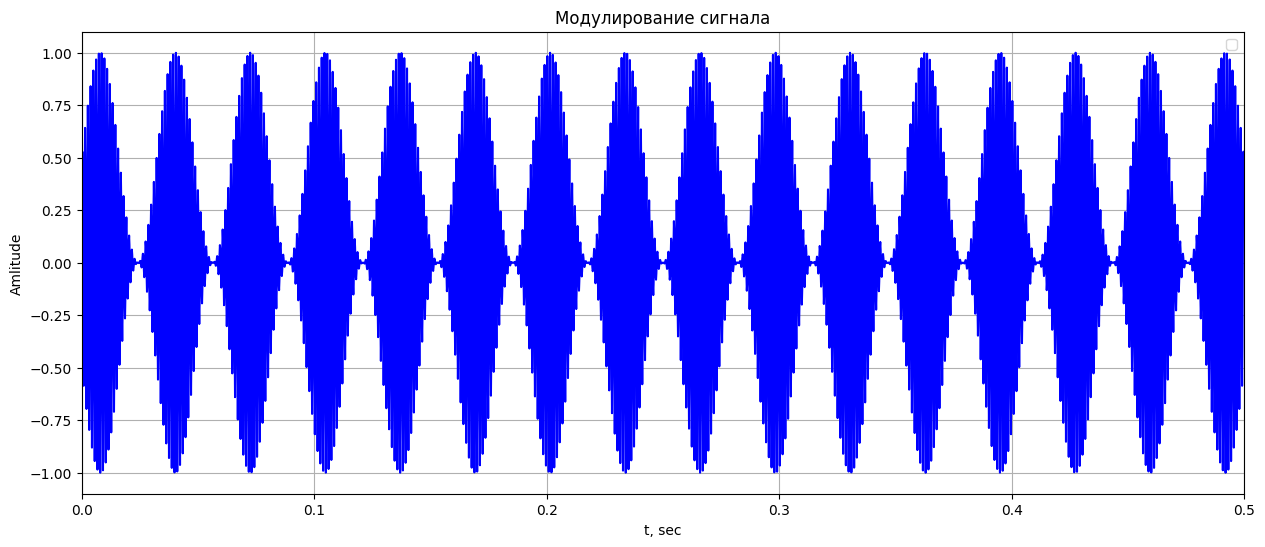

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, signal, color='blue')
plt.title("Модулирование сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, TIME_END, -1.1, 1.1])
plt.grid(True)
plt.legend()
plt.show()

Добавим шум (равномерно распределенная случайная величина) относительно нулевой амплитуды

In [ ]:
noise_10 = 0.2 * np.random.uniform(0, 1, size=N) - 0.1
noise_35 = 0.7 * np.random.uniform(0, 1, size=N) - 0.35
noise_65 = 1.3 * np.random.uniform(0, 1, size=N) - 0.65

mod_sig_10 = signal +noise_10
mod_sig_35 = signal +noise_35
mod_sig_65 = signal +noise_65

signal_10_norm = 2 * (mod_sig_10 - mod_sig_10.min()) / (mod_sig_10.max() - mod_sig_10.min()) - 1
signal_35_norm = 2 * (mod_sig_35 - mod_sig_35.min()) / (mod_sig_35.max() - mod_sig_35.min()) - 1
signal_65_norm = 2 * (mod_sig_65 - mod_sig_65.min()) / (mod_sig_65.max() - mod_sig_65.min()) - 1

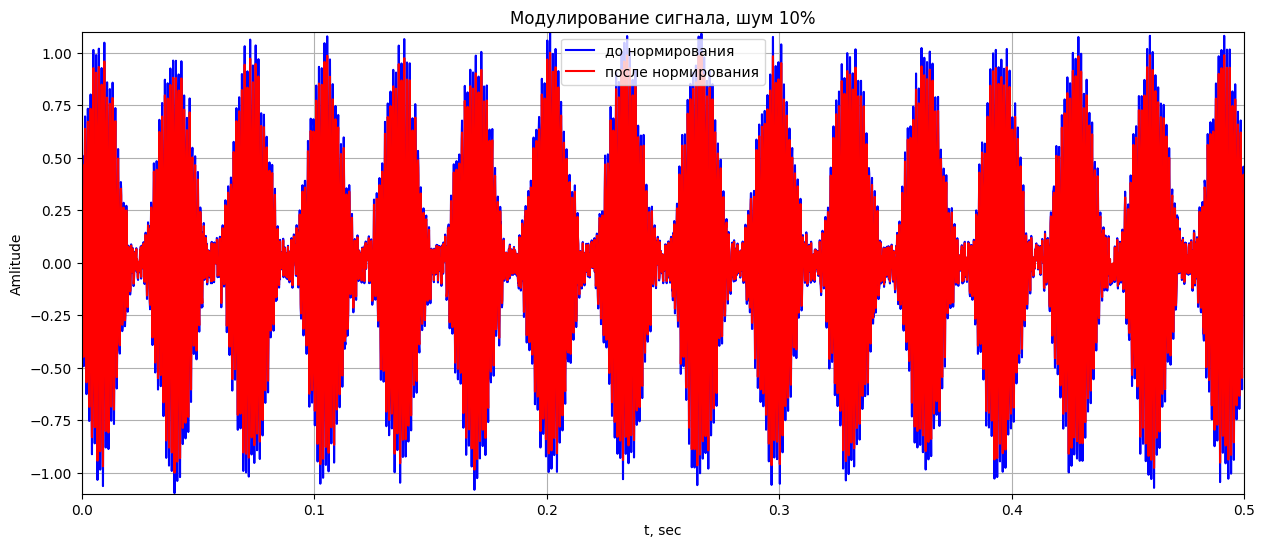

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, mod_sig_10, color='blue', label='до нормирования')
plt.plot(t, signal_10_norm, color='red',  label='после нормирования')
plt.title("Модулирование сигнала, шум 10%")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, TIME_END, -1.1, 1.1])
plt.grid(True)
plt.legend()
plt.show()

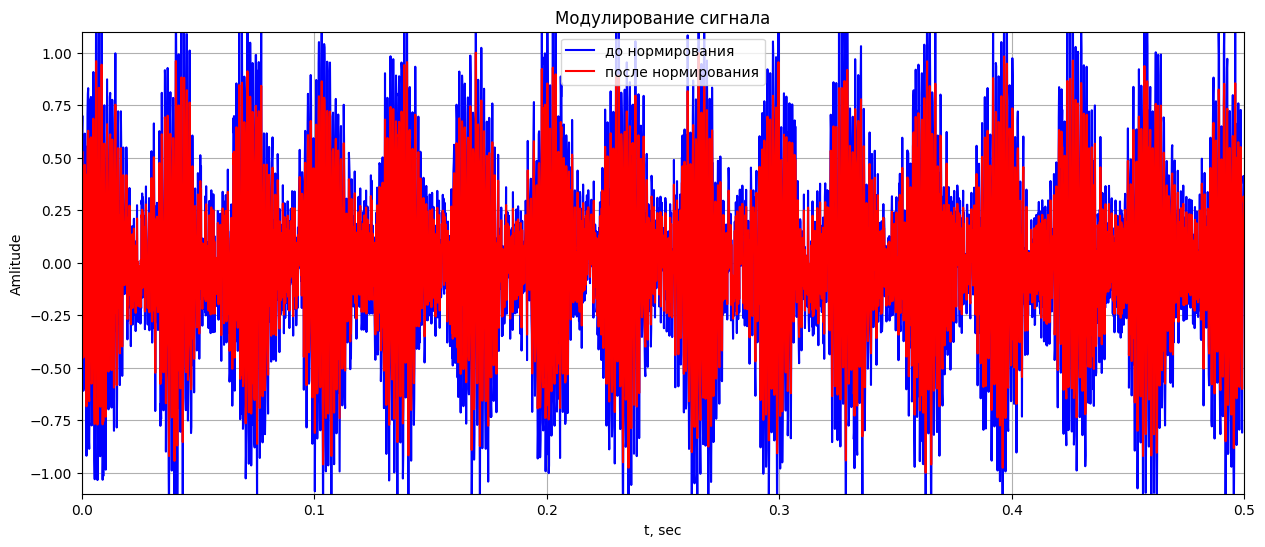

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, mod_sig_35, color='blue',  label='до нормирования')
plt.plot(t, signal_35_norm, color='red',  label='после нормирования')
plt.title("Модулирование сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, TIME_END, -1.1, 1.1])
plt.grid(True)
plt.legend()
plt.show()

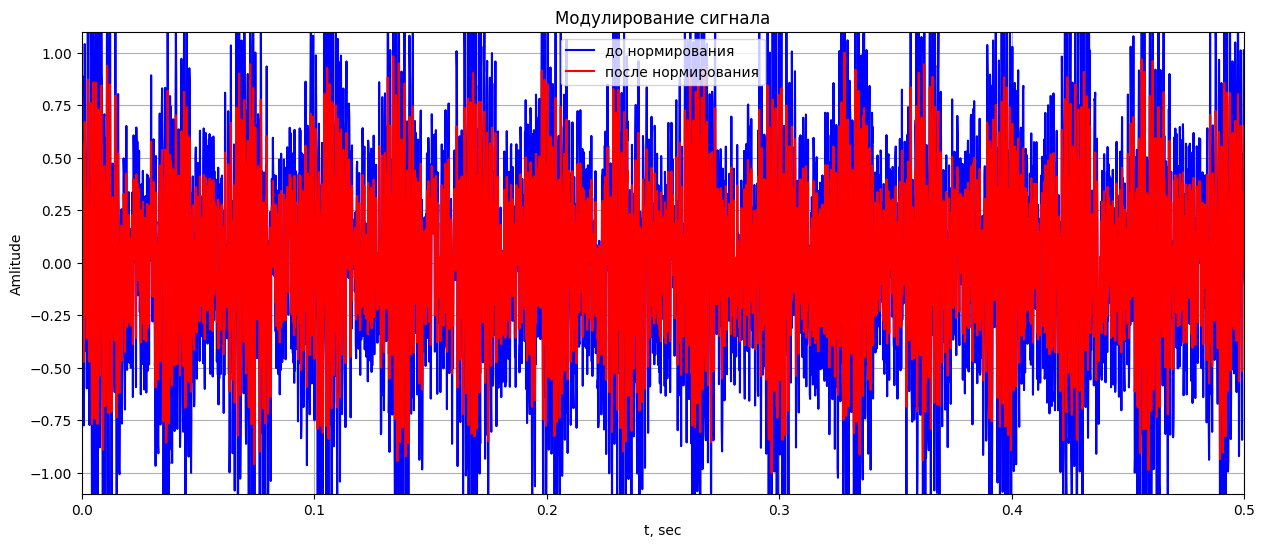

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, mod_sig_65, color='blue',  label='до нормирования')
plt.plot(t, signal_65_norm, color='red',  label='после нормирования')
plt.title("Модулирование сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, TIME_END, -1.1, 1.1])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
y_10 = np.floor((signal_10_norm + M) * QUAN_LV/(2*M))
y_35 = np.floor((signal_35_norm + M) * QUAN_LV/(2*M))
y_65 = np.floor((signal_65_norm + M) * QUAN_LV/(2*M))

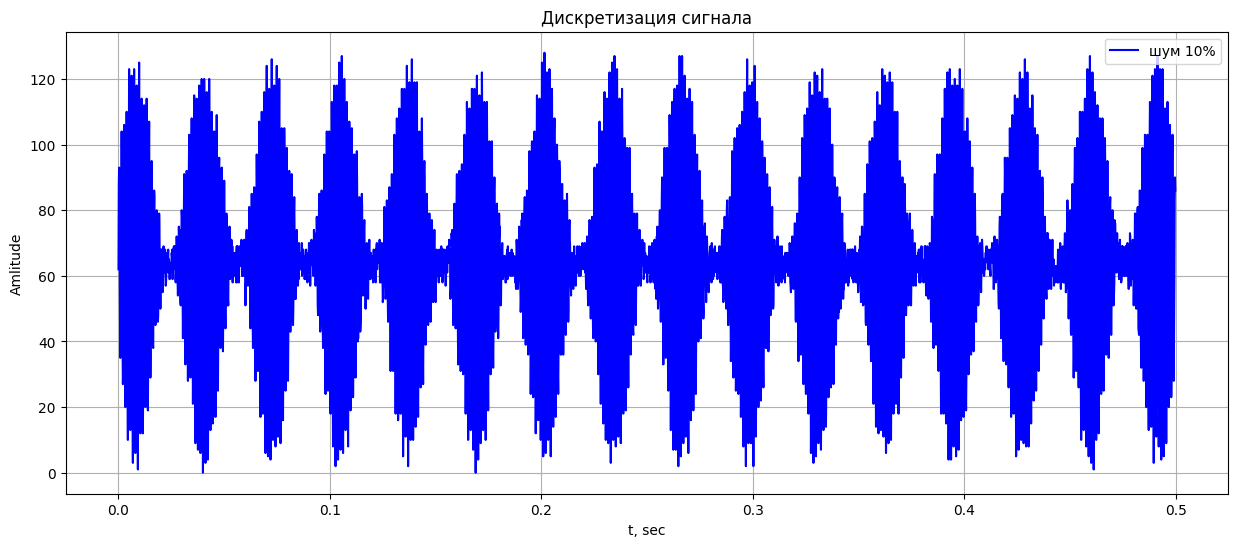

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, y_10, color='blue',  label='шум 10%')
plt.title("Дискретизация сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.grid(True)
plt.legend()
plt.show()

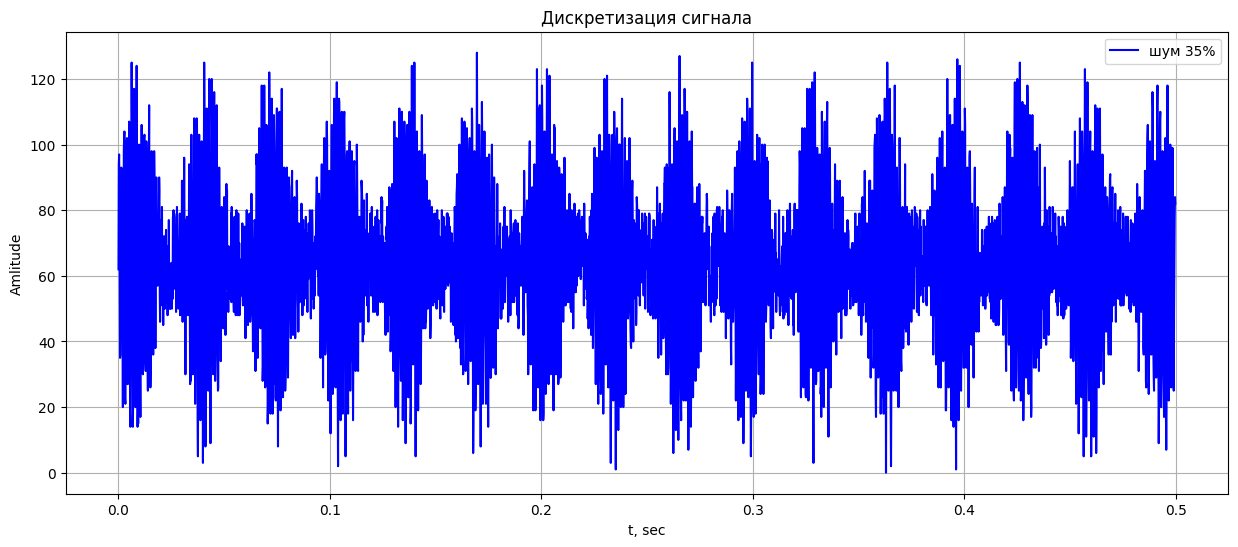

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, y_35, color='blue',  label='шум 35%')
plt.title("Дискретизация сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.grid(True)
plt.legend()
plt.show()

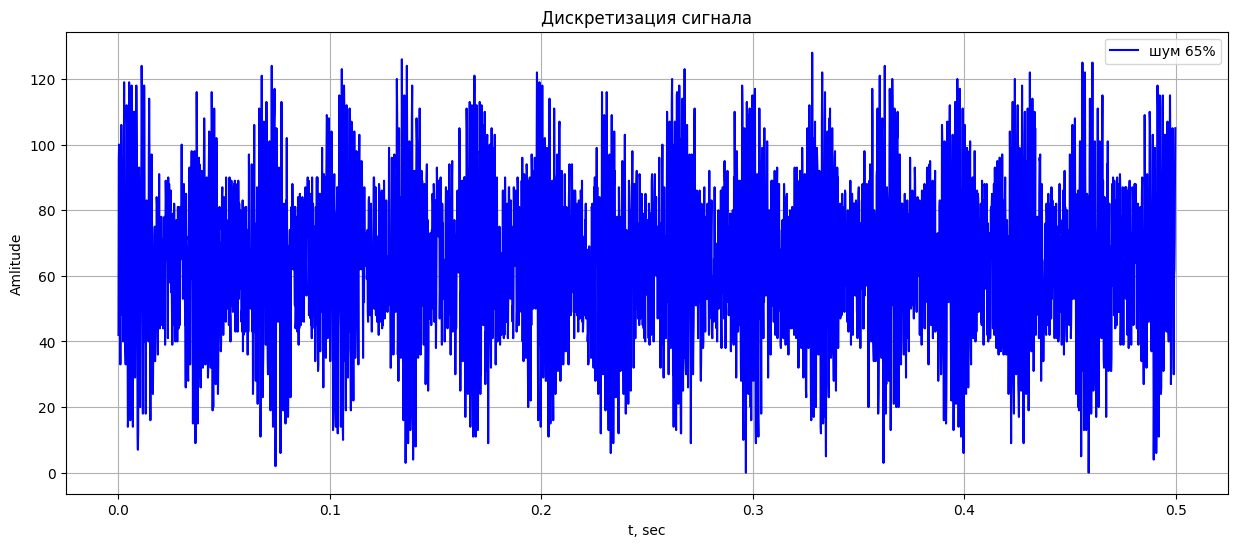

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, y_65, color='blue',  label='шум 65%')
plt.title("Дискретизация сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.grid(True)
plt.legend()
plt.show()

Проведем фильтрацию зашумленных сигналов

In [ ]:
def freq_transfer_1(sig, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, n_but=6):
  sin_out = sig * np.sin((np.arange(N) - 1) * 2 * np.pi * FREQ_CAR / SAMPLE_RATE)
  cos_out = sig * np.cos((np.arange(N) - 1) * 2 * np.pi * FREQ_CAR / SAMPLE_RATE)
  b,a = sci.signal.butter(n_but, FREQ_MOD * K_DISC /(2*SAMPLE_RATE))
  sin_out_butt = sci.signal.lfilter(b, a, sin_out)
  cos_out_butt = sci.signal.lfilter(b, a, cos_out)
  detection = np.sqrt(sin_out_butt **2 + cos_out_butt **2)
  return detection

In [ ]:
def freq_transfer_2(sig, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, n_but=6, k_but=1):
  sin_out = sig * np.sin((np.arange(N) - 1) * 2 * np.pi * FREQ_MOD / SAMPLE_RATE)
  cos_out = sig * np.cos((np.arange(N) - 1) * 2 * np.pi * FREQ_MOD / SAMPLE_RATE)

  b,a = sci.signal.butter(n_but, FREQ_MOD * K_DISC /(2*8*SAMPLE_RATE))
  sin_out_butt = sci.signal.lfilter(b, a, sin_out)
  cos_out_butt = sci.signal.lfilter(b, a, cos_out)
  detection = np.sqrt(sin_out_butt **2 + cos_out_butt **2)
  return detection

In [ ]:
#signal_65_norm
detection_2 = freq_transfer_1(signal_10_norm, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE)
detection_4 = freq_transfer_1(signal_35_norm, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE)
detection_6 = freq_transfer_1(signal_65_norm, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE)

cnt = len(t) / 4;
mid2 = sum(detection_2[int(cnt):2*int(cnt)])
mid4 = sum(detection_4[int(cnt):2*int(cnt)])
mid6 = sum(detection_6[int(cnt):2*int(cnt)])


mid2 = mid2 / cnt * 0.708
mid4 = mid4 / cnt * 0.708
mid6 = mid6 / cnt * 0.708

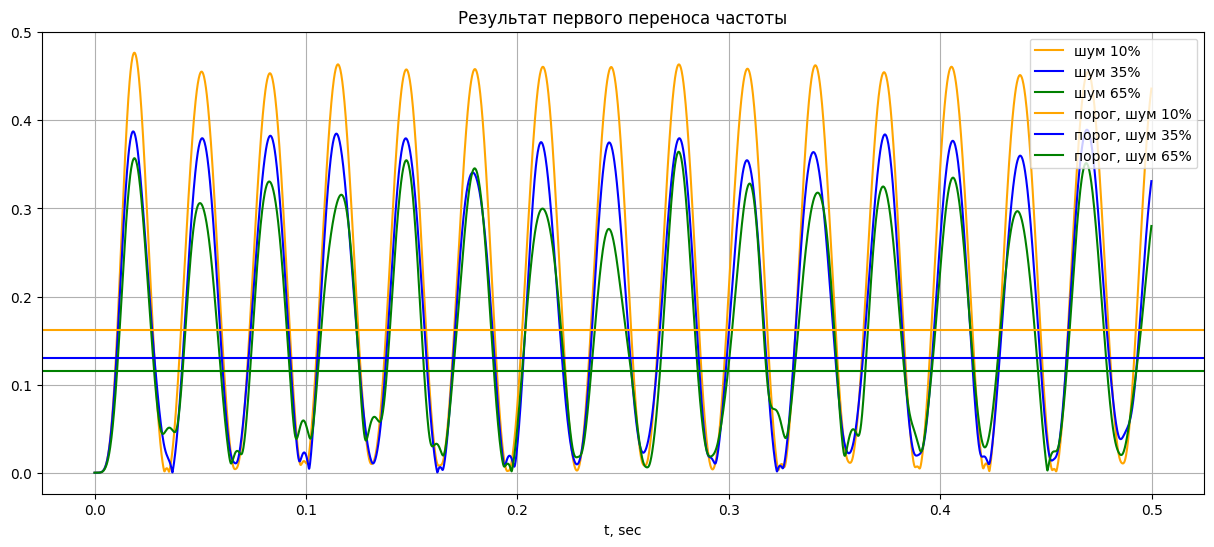

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, detection_2, label='шум 10%', color='orange')
plt.plot(t, detection_4, label='шум 35%', color='blue')
plt.plot(t, detection_6, label='шум 65%', color='green')
plt.axhline(y=mid2, label='порог, шум 10%', color='orange')
plt.axhline(y=mid4, label='порог, шум 35%', color='blue')
plt.axhline(y=mid6, label='порог, шум 65%', color='green')
plt.title("Результат первого переноса частоты")
plt.xlabel("t, sec")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
detection_2_2 = freq_transfer_2(detection_2, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, k_but=8)
detection_4_2 = freq_transfer_2(detection_4, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, k_but=8)
detection_6_2 = freq_transfer_2(detection_6, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, k_but=8)

cnt = len(t) / 4;
mid2 = sum(detection_2_2[int(cnt):2*int(cnt)])
mid4 = sum(detection_4_2[int(cnt):2*int(cnt)])
mid6 = sum(detection_6_2[int(cnt):2*int(cnt)])


mid2 = mid2 / cnt * 0.708
mid4 = mid4 / cnt * 0.708
mid6 = mid6 / cnt * 0.708

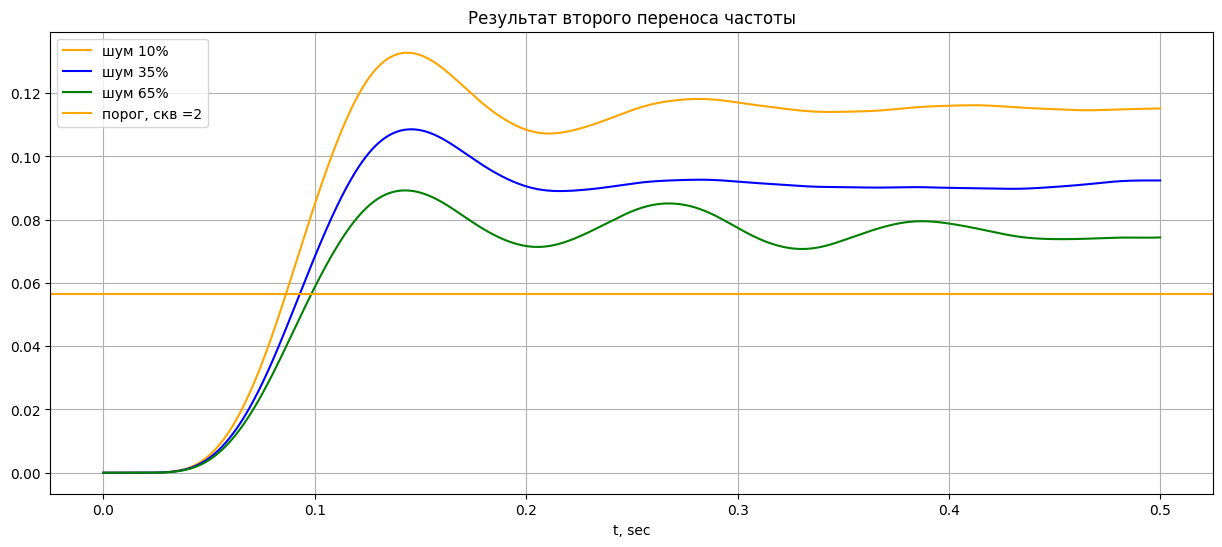

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, detection_2_2, label='шум 10%', color='orange')
plt.plot(t, detection_4_2, label='шум 35%', color='blue')
plt.plot(t, detection_6_2, label='шум 65%', color='green')
plt.axhline(y=mid6, label='порог, скв =2', color='orange')
#plt.axhline(y=mid_4_2, label='порог, скв =4', color='blue')
#plt.axhline(y=11.600348147723475, label='порог', color='red')
plt.title("Результат второго переноса частоты")
plt.xlabel("t, sec")
#plt.axis([0, 0.5, 0, 0.003])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def det_sig(lbound, signal):
  res = []
  for i in range(N):
    tt = signal[i]
    if tt <= lbound:
      res.append(0)
    else:
      res.append(1)
  return res

In [ ]:
det_2 = det_sig(signal=detection_2, lbound=0.0600348147723475)
det_4 = det_sig(signal=detection_4, lbound=0.0600348147723475)
det_6 = det_sig(signal=detection_6, lbound=0.0600348147723475)

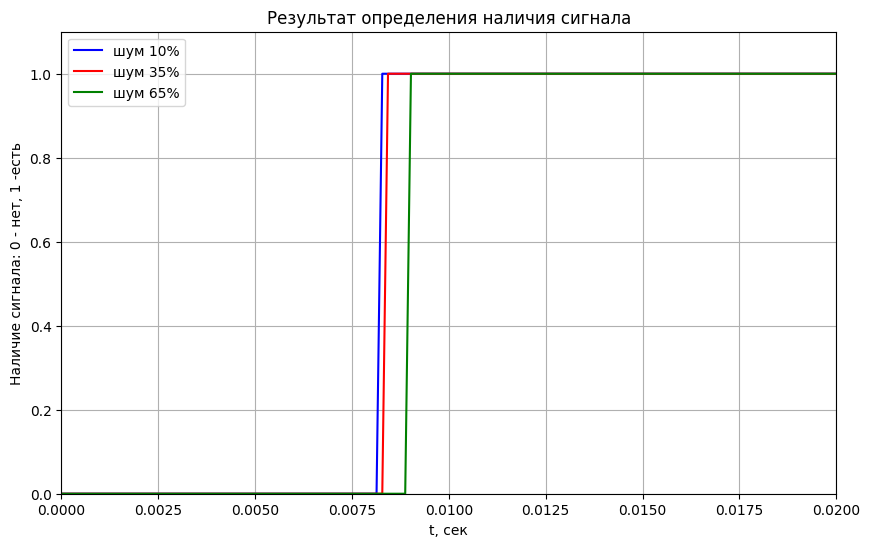

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, det_2, color='blue', label='шум 10%')
plt.plot(t, det_4, color='red', label='шум 35%')
plt.plot(t, det_6, color='green', label='шум 65%')
plt.title("Результат определения наличия сигнала")
plt.xlabel("t, сек")
plt.ylabel("Наличие сигнала: 0 - нет, 1 -есть")
plt.grid(True)
plt.axis([0, 0.02, 0, 1.1])
plt.legend()
plt.show()

In [ ]:
k = 1
while det_2[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

k = 1
while det_4[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

k = 1
while det_6[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

Задержка составляет:  0.008284023668639054
Задержка составляет:  0.008431952662721894
Задержка составляет:  0.009023668639053255


Взять за основу модель приемника (лаб. раб. 2) с рекурсивным фильтром 4 порядка. Входной сигнал изменить: до 7-го периода частоты модуляции – сигнал тот же (не меняется), далее 8-9 периоды скачком уменьшается частота несущая Ftr на 30%, а амплитуда уменьшается в 2 раза. После 9-го периода – сигнал с исходными параметрами.

In [ ]:
#Константы
FREQ_CAR = 845                  #Несущая частота
FREQ_MOD = 31                   #Модулируемая частота
QUAN_LV = 128                   #Число уровней квантования
TIME_END = 0.5                  #Время моделирования
PHASE_MOD = 0                   #Фаза моделируемой частоты
PHASE_CAR = 0                   #Фаза несущей частоты
M = 1                           #Коэффициент модуляции
K_DISC = 8
SAMPLE_RATE = FREQ_CAR * K_DISC #Частота дискретизации
SAMPLE_PER = 1/SAMPLE_RATE      #Период дискретизации

In [ ]:
t = np.arange(0, TIME_END, SAMPLE_PER)
N = len(t)
signal = np.zeros(N)
for tt in range(N):
  time = t[tt]
  if time <= 7 /FREQ_MOD:
    signal[tt] = 0.5 * (1 + M * np.sin(2 * np.pi * FREQ_MOD * time + PHASE_MOD)) * np.sin(2 * np.pi * time * FREQ_CAR + PHASE_CAR)
  elif (time > (7 / FREQ_MOD)) & (time <= (9 / FREQ_MOD)):
    signal[tt] = 0.25 * (1 + M * np.sin(2 * np.pi * FREQ_MOD * time + PHASE_MOD)) * np.sin(2 * np.pi * time * FREQ_CAR * 0.7 + PHASE_CAR)
  else:
    signal[tt] = 0.5 * (1 + M * np.sin(2 * np.pi * FREQ_MOD * time + PHASE_MOD)) * np.sin(2 * np.pi * time * FREQ_CAR + PHASE_CAR)
disc_mod_sig = np.floor((signal + M) * QUAN_LV / (2*M))

/tmp/ipython-input-3502200227.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


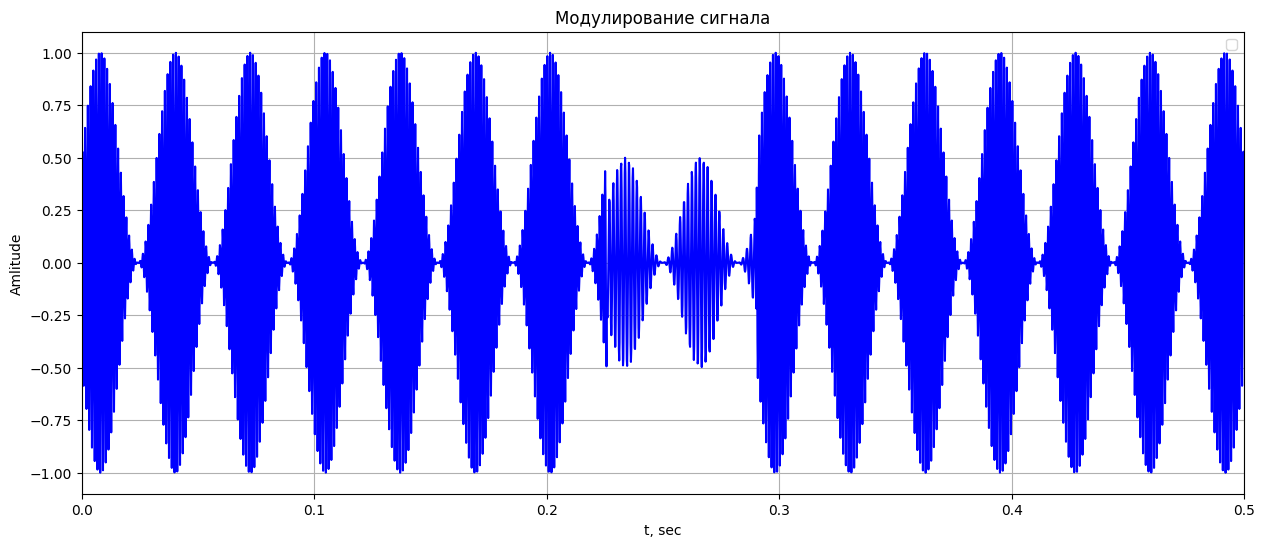

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, signal, color='blue')
plt.title("Модулирование сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, TIME_END, -1.1, 1.1])
plt.grid(True)
plt.legend()
plt.show()

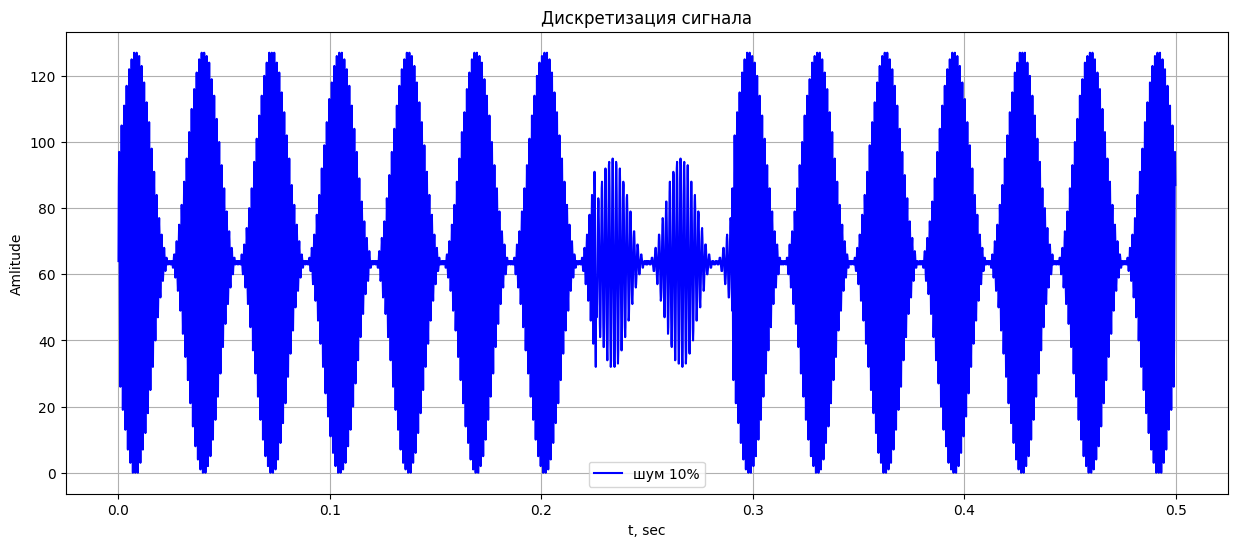

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, disc_mod_sig, color='blue',  label='шум 10%')
plt.title("Дискретизация сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
detection = freq_transfer_1(disc_mod_sig, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE)

/tmp/ipython-input-135466440.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


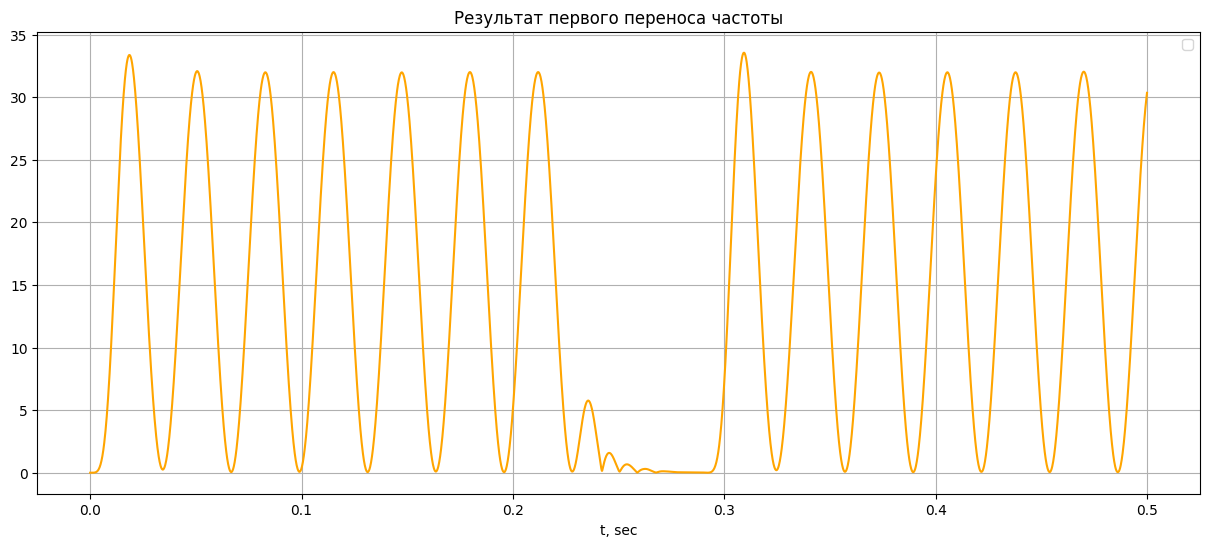

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, detection, color='orange')
plt.title("Результат первого переноса частоты")
plt.xlabel("t, sec")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
detection_ = freq_transfer_2(detection, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, k_but=8)

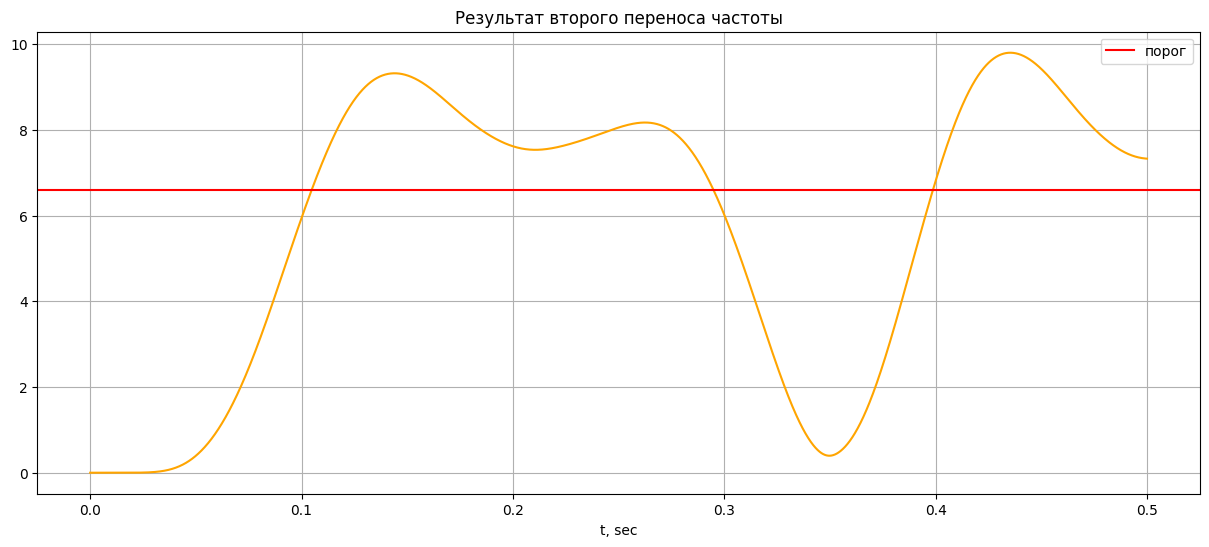

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, detection_, color='orange')
plt.axhline(y=6.600348147723475, label='порог', color='red')
plt.title("Результат второго переноса частоты")
plt.xlabel("t, sec")
#plt.axis([0, 0.5, 0, 0.003])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
det_ = det_sig(signal=detection_, lbound=6.0600348147723475)

/tmp/ipython-input-310532014.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


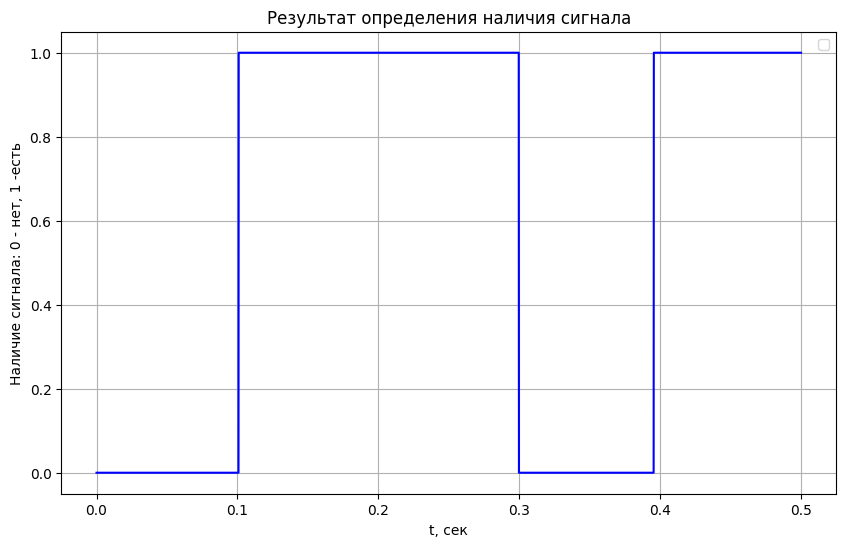

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, det_, color='blue')

plt.title("Результат определения наличия сигнала")
plt.xlabel("t, сек")
plt.ylabel("Наличие сигнала: 0 - нет, 1 -есть")
plt.grid(True)

plt.legend()
plt.show()

In [ ]:
k = 1
while det_[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

Задержка составляет:  0.10088757396449705
